In [27]:
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
#2b
((norm.cdf(0.6)-norm.cdf(-0.6))/(2*0.6))

np.float64(0.3762448037498774)

In [29]:
#2e
((norm.cdf(0.1)-norm.cdf(-0.1))/(2*0.1))

np.float64(0.3982783727702899)

In [30]:
#3b
X = np.array([5, 7, 7, 8, 10])
h = 1.5
n = len(X)

for x in [6.0, 6.5, 7.0, 8.0, 8.5]:
    uniform = (np.abs(X - x) < h).sum() / (2 * n * h)
    gaussian = norm.pdf((x - X) / h).sum() / (n * h)
    print(f"x = {x}", f"unifkern = {round(uniform, 3)}", f"gausskern = {round(gaussian, 3)}")

x = 6.0 unifkern = 0.2 gausskern = 0.151
x = 6.5 unifkern = 0.133 gausskern = 0.169
x = 7.0 unifkern = 0.2 gausskern = 0.178
x = 8.0 unifkern = 0.2 gausskern = 0.167
x = 8.5 unifkern = 0.067 gausskern = 0.151


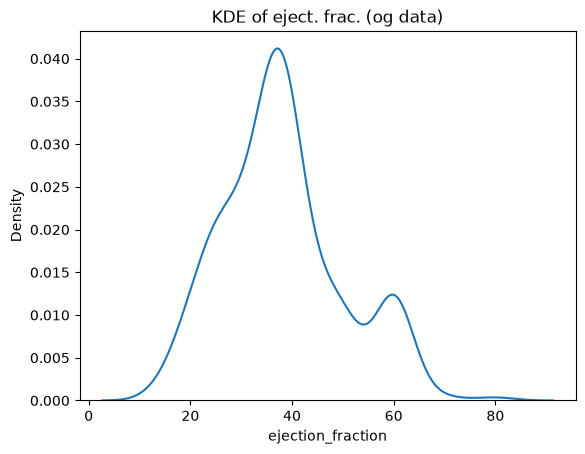

In [ ]:
#4a
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

sns.kdeplot(data=df, x='ejection_fraction')
plt.title('KDE of eject. frac. (og data)')
plt.show()


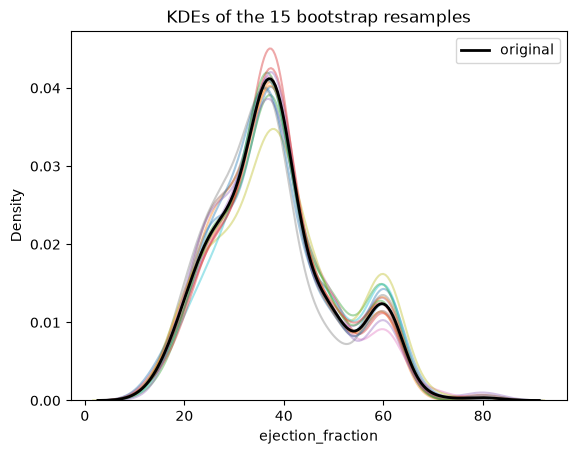

In [49]:
#4b
for i in range(15):
    resample = df.sample(frac=1.0, replace=True)
    sns.kdeplot(data=resample, x='ejection_fraction',
            alpha=0.4)

sns.kdeplot(data=df, x='ejection_fraction',
            color='black', linewidth=2, label='original')
plt.title('KDEs of the 15 bootstrap resamples')
plt.legend()
plt.show()

4c) The original KDE is most reliable where the 15 resample lines overlap the original the most: in the tail below ~15, on the rising slope from (~10- ~22) and the falling slope (~40-~45). The least reliable are the parts of the curve where the resample lines vary in height greatly from eachother/the original: the top of the main peak near 37 (heights from ~0.035- ~0.045), at the second bump near 60 (~0.010- ~0.015), & in the stretch from ~46 to ~55 between them. So, the original KDE is trustworthy for the overall shape and the slopes, but the exact height of the peaks and depth of the valley depend on which patients were sampled, so those details aren't very precise.